In [22]:
import os
import json
import pandas as pd

# --- 配置路径 ---
BASE_DIR = r"G:\jupyter\2025APMCM"
TARIFF_DIR = os.path.join(BASE_DIR, "Tariff Data")
JSON_FILE = os.path.join(BASE_DIR, "tariff_columns_by_year.json")

print(f"Working Directory: {BASE_DIR}")

# 1. 检查元数据 JSON
if os.path.exists(JSON_FILE):
    with open(JSON_FILE, 'r') as f:
        cols_meta = json.load(f)
    print(f"[OK] JSON Metadata loaded. Keys: {list(cols_meta.keys())}")
else:
    print(f"[ERROR] JSON file not found at: {JSON_FILE}")

# 2. 检查各年份文件存在性
years = range(2015, 2026) # 2015 to 2025
available_files = {}

print("\n--- File Inventory Check ---")
for year in years:
    year_str = str(year)
    folder_path = os.path.join(TARIFF_DIR, f"tariff_data_{year}")
    
    # 构造可能的文件名
    file_txt = os.path.join(folder_path, f"tariff_database_{year}.txt")
    file_xlsx = os.path.join(folder_path, f"tariff_database_{year}.xlsx")
    file_csv = os.path.join(folder_path, f"tariff_database_{year}.csv") # 以防万一
    
    found_path = None
    
    if os.path.exists(file_txt):
        found_path = file_txt
        print(f"[OK] {year}: Found TXT")
    elif os.path.exists(file_xlsx):
        found_path = file_xlsx
        print(f"[OK] {year}: Found XLSX")
    elif os.path.exists(file_csv):
        found_path = file_csv
        print(f"[OK] {year}: Found CSV")
    else:
        print(f"[MISSING] {year}: No standard data file found in {folder_path}")
    
    if found_path:
        available_files[year] = found_path

# 3. 采样读取 (2015 和 2025) 以检查格式
print("\n--- Sample Reading (Head 3 rows) ---")
test_years = [2015, 2025]

for y in test_years:
    if y in available_files:
        fpath = available_files[y]
        try:
            print(f"\nReading {y} from {os.path.basename(fpath)}...")
            
            # 尝试读取逻辑
            if fpath.endswith('.txt') or fpath.endswith('.csv'):
                # 尝试推断分隔符，先读第一行
                with open(fpath, 'r', encoding='utf-8', errors='ignore') as f:
                    first_line = f.readline()
                    print(f"Raw Header Sample: {first_line.strip()[:100]}...")
                
                # 尝试用 pandas 读取，假设是逗号或管道符
                try:
                    df_temp = pd.read_csv(fpath, sep=None, engine='python', nrows=3)
                except:
                    df_temp = pd.read_csv(fpath, sep='|', encoding='latin1', nrows=3)
                    
            elif fpath.endswith('.xlsx'):
                df_temp = pd.read_excel(fpath, nrows=3)
            
            print("Columns detected:", list(df_temp.columns)[:5], "...")
            print(f"Shape: {df_temp.shape}")
        except Exception as e:
            print(f"[ERROR] Failed to read {y}: {e}")

Working Directory: G:\jupyter\2025APMCM
[OK] JSON Metadata loaded. Keys: ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']

--- File Inventory Check ---
[OK] 2015: Found TXT
[OK] 2016: Found TXT
[OK] 2017: Found TXT
[OK] 2018: Found TXT
[OK] 2019: Found XLSX
[OK] 2020: Found XLSX
[OK] 2021: Found XLSX
[OK] 2022: Found XLSX
[OK] 2023: Found XLSX
[OK] 2024: Found XLSX
[OK] 2025: Found TXT

--- Sample Reading (Head 3 rows) ---

Reading 2015 from tariff_database_2015.txt...
Raw Header Sample: hts8|brief_description|quantity_1_code|quantity_2_code|wto_binding_code|mfn_text_rate|mfn_rate_type_...
Columns detected: ['hts8|brief_description|qu', 'ntity_1_code|qu', 'ntity_2_code|wto_binding_code|mfn_text_r', 'te|mfn_r', 'te_type_code|mfn_'] ...
Shape: (3, 257)

Reading 2025 from tariff_database_2025.txt...
Raw Header Sample: hts8,brief_description,quantity_1_code,quantity_2_code,wto_binding_code,mfn_text_rate,mfn_rate_type_...
Columns detected: ['hts8', 'b

In [20]:
import pandas as pd
import os
import numpy as np

# --- Config ---
BASE_DIR = r"G:\jupyter\2025APMCM"
TARIFF_DIR = os.path.join(BASE_DIR, "Tariff Data")

def read_tariff_year(year):
    """
    Robustly reads tariff data for a specific year.
    Returns a DataFrame with standardized columns: ['hts8', 'mfn_ad_val_rate']
    """
    year_str = str(year)
    folder_path = os.path.join(TARIFF_DIR, f"tariff_data_{year}")
    
    # Determine file path and type
    file_txt = os.path.join(folder_path, f"tariff_database_{year}.txt")
    file_xlsx = os.path.join(folder_path, f"tariff_database_{year}.xlsx")
    
    df = None
    
    try:
        # Strategy 1: Excel (2019-2024)
        if os.path.exists(file_xlsx):
            print(f"[{year}] Loading XLSX...")
            # Read header first to sanitize columns if needed
            df = pd.read_excel(file_xlsx, dtype={'hts8': str})
            
        # Strategy 2: TXT (2015-2018, 2025)
        elif os.path.exists(file_txt):
            # Heuristic to determine separator
            sep = '|' # Default for early years
            if year == 2025:
                sep = ',' # New format
            
            print(f"[{year}] Loading TXT with sep='{sep}'...")
            
            # Use low_memory=False to avoid mixed type warnings, read hts8 as string
            df = pd.read_csv(file_txt, sep=sep, encoding='latin1', 
                             dtype={'hts8': str}, on_bad_lines='skip')
            
        else:
            print(f"[{year}] FILE NOT FOUND.")
            return None

        # Standardize Column Names (lowercase)
        df.columns = [c.lower().strip() for c in df.columns]
        
        # Validate HTS8 length (must be 8 digits, sometimes read as float)
        if 'hts8' in df.columns:
            # Remove dots if they exist (e.g. 1201.90.00 -> 12019000)
            df['hts8'] = df['hts8'].astype(str).str.replace('.', '', regex=False).str.strip()
            # Pad with zeros if somehow shortened (though unlikely for string read)
            df = df[df['hts8'].str.len() >= 4] # Filter out garbage rows
        
        # Handle mfn_ad_val_rate (convert to numeric, handle "Free" or nan)
        if 'mfn_ad_val_rate' in df.columns:
            # Usually these are strings like "2.5%" or "Free"
            # We need to clean this.
            pass 
        else:
            print(f"[{year}] WARNING: 'mfn_ad_val_rate' column missing!")
            
        return df
        
    except Exception as e:
        print(f"[{year}] CRITICAL ERROR: {e}")
        return None

def clean_rate_column(series):
    """
    Converts tariff rate column to float.
    'Free' -> 0.0
    '2.5%' -> 0.025 (or 2.5, let's check data first)
    NaN -> 0.0
    """
    # Convert to string first
    s = series.astype(str).str.lower().str.strip()
    
    # Handle 'free'
    s = s.replace({'free': '0', 'nan': '0', 'nm': '0'})
    
    # Extract numeric part if mixed (simple regex or force coerce)
    # Some entries might be "2.5% + 1c/kg", we only want the ad valorem part for now
    # Or just force numeric errors='coerce'
    
    # Remove '%'
    s = s.str.replace('%', '', regex=False)
    
    vals = pd.to_numeric(s, errors='coerce').fillna(0.0)
    
    # Check scaling: if max > 1, it's likely percentage (e.g. 2.5), not ratio (0.025)
    # We will inspect this in the print output.
    return vals

# --- Execution: Test 2015, 2020, 2025 ---
test_years = [2015, 2020, 2025]
summary_stats = []

for y in test_years:
    df = read_tariff_year(y)
    if df is not None:
        # Clean Rate
        raw_vals = df['mfn_ad_val_rate'].head().tolist()
        df['rate_clean'] = clean_rate_column(df['mfn_ad_val_rate'])
        
        mean_rate = df['rate_clean'].mean()
        max_rate = df['rate_clean'].max()
        zeros = (df['rate_clean'] == 0).mean()
        
        summary_stats.append({
            'Year': y,
            'Raw_Sample': str(raw_vals),
            'Mean_Rate': mean_rate,
            'Max_Rate': max_rate,
            'Zero_Tariff_Pct': zeros
        })

print("\n--- Tariff Rate Analysis (MFN) ---")
print(pd.DataFrame(summary_stats))

[2015] Loading XLSX...
[2020] Loading XLSX...
[2025] Loading XLSX...

--- Tariff Rate Analysis (MFN) ---
   Year                     Raw_Sample   Mean_Rate     Max_Rate  \
0  2015  [0.0, 0.0, 0.068, 0.0, 0.045]  483.703303  9999.999999   
1  2020  [0.0, 0.0, 0.068, 0.068, 0.0]  377.081712  9999.999999   
2  2025  [0.0, 0.0, 0.068, 0.0, 0.045]  505.714241  9999.999999   

   Zero_Tariff_Pct  
0         0.477544  
1         0.375033  
2         0.467848  


In [24]:
import pandas as pd
import os
import numpy as np

# --- Config ---
BASE_DIR = r"G:\jupyter\2025APMCM"
TARIFF_DIR = os.path.join(BASE_DIR, "Tariff Data")

def analyze_rate_distribution(year):
    folder_path = os.path.join(TARIFF_DIR, f"tariff_data_{year}")
    # 既然上次确认优先读 XLSX 成功，我们保持这个逻辑
    file_xlsx = os.path.join(folder_path, f"tariff_database_{year}.xlsx")
    file_txt = os.path.join(folder_path, f"tariff_database_{year}.txt")
    
    df = None
    try:
        if os.path.exists(file_xlsx):
            df = pd.read_excel(file_xlsx, dtype={'hts8': str})
        elif os.path.exists(file_txt):
            # Fallback to TXT if XLSX missing (robustness)
            sep = ',' if year == 2025 else '|'
            df = pd.read_csv(file_txt, sep=sep, encoding='latin1', dtype={'hts8': str}, on_bad_lines='skip')
            
        if df is None: return None

        # Standardize columns
        df.columns = [c.lower().strip() for c in df.columns]
        
        # Clean Rate Column
        # 1. Convert to numeric, coercing errors
        s = df['mfn_ad_val_rate'].astype(str).str.replace('%', '', regex=False)
        s = s.replace({'free': '0', 'nan': '0', 'nm': '0'})
        vals = pd.to_numeric(s, errors='coerce').fillna(0.0)
        
        # 2. Filter out the '9999' noise code (ITC placeholder)
        # Realistically, anything > 1 (100%) is suspicious for a general average, 
        # but let's set cut-off at 5 (500%) just to be safe, and strictly exclude 9999.
        valid_mask = vals < 10.0 
        clean_vals = vals[valid_mask]
        
        high_vals = vals[vals >= 10.0]
        
        return {
            'Year': year,
            'Original_Count': len(vals),
            'Valid_Count': len(clean_vals),
            'Noise_Count (>=10)': len(high_vals),
            'Clean_Mean': clean_vals.mean(),
            'Clean_Median': clean_vals.median(),
            'Clean_Max': clean_vals.max(),
            'Clean_Std': clean_vals.std()
        }

    except Exception as e:
        return {'Year': year, 'Error': str(e)}

# --- Run Analysis for key years ---
years_to_check = [2015, 2018, 2020, 2024, 2025]
results = []

print("--- Deep Cleaning Analysis ---")
for y in years_to_check:
    print(f"Processing {y}...")
    res = analyze_rate_distribution(y)
    results.append(res)

stats_df = pd.DataFrame(results)
print("\n", stats_df[['Year', 'Clean_Mean', 'Clean_Median', 'Noise_Count (>=10)', 'Valid_Count']])

# Check specifically if 2025 is still "low tariff"
mean_2025 = stats_df[stats_df['Year'] == 2025]['Clean_Mean'].values[0]
if mean_2025 < 0.10:
    print(f"\n[CONCLUSION] 2025 Clean Mean is {mean_2025:.4f} ({mean_2025*100:.2f}%).")
    print("This confirms the data is PRE-SHOCK. We must model the Trump tariffs manually.")
else:
    print(f"\n[CONCLUSION] 2025 Clean Mean is high ({mean_2025:.4f}). Data might already include shock.")

--- Deep Cleaning Analysis ---
Processing 2015...
Processing 2018...
Processing 2020...
Processing 2024...
Processing 2025...

    Year  Clean_Mean  Clean_Median  Noise_Count (>=10)  Valid_Count
0  2015    0.036739         0.000                 616        12120
1  2018    0.037585         0.012                 622        12578
2  2020    0.044436         0.030                 846        21592
3  2024    0.037490         0.006                 455        12520
4  2025    0.037823         0.011                 659        12373

[CONCLUSION] 2025 Clean Mean is 0.0378 (3.78%).
This confirms the data is PRE-SHOCK. We must model the Trump tariffs manually.


In [30]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Config ---
BASE_DIR = r"G:\jupyter\2025APMCM"
TARIFF_DIR = os.path.join(BASE_DIR, "Tariff Data")
OUTPUT_DIR = os.path.join(BASE_DIR, "Cleaned_Data")
SAVE_PATH = os.path.join(OUTPUT_DIR, "Figure_1_Tariff_Baseline.png")

# Ensure output directory exists
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# Set academic style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 12

def get_clean_rates(year):
    folder_path = os.path.join(TARIFF_DIR, f"tariff_data_{year}")
    file_xlsx = os.path.join(folder_path, f"tariff_database_{year}.xlsx")
    file_txt = os.path.join(folder_path, f"tariff_database_{year}.txt")
    
    try:
        if os.path.exists(file_xlsx):
            df = pd.read_excel(file_xlsx, dtype={'hts8': str})
        elif os.path.exists(file_txt):
            sep = ',' if year == 2025 else '|'
            df = pd.read_csv(file_txt, sep=sep, encoding='latin1', dtype={'hts8': str}, on_bad_lines='skip')
        else:
            return pd.Series(dtype=float)
        
        if df is not None:
            df.columns = [c.lower().strip() for c in df.columns]
            if 'mfn_ad_val_rate' not in df.columns: return pd.Series(dtype=float)
            s = df['mfn_ad_val_rate'].astype(str).str.replace('%', '', regex=False)
            s = s.replace({'free': '0', 'nan': '0', 'nm': '0'})
            vals = pd.to_numeric(s, errors='coerce').fillna(0.0)
            return vals[vals < 10.0] 
    except:
        return pd.Series(dtype=float)

# 1. Get Data
years = range(2015, 2026)
yearly_means = []
data_2025 = None

print("Generating corrected plot...")
for y in years:
    rates = get_clean_rates(y)
    if not rates.empty:
        yearly_means.append({'Year': y, 'Mean_Rate': rates.mean() * 100})
        if y == 2025:
            data_2025 = rates * 100

ts_df = pd.DataFrame(yearly_means)

# 2. Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # Standard Aspect Ratio

# Left: Trend (Fixing the scale issue)
sns.lineplot(data=ts_df, x='Year', y='Mean_Rate', marker='o', markersize=8, ax=axes[0], linewidth=2.5, color='#2b579a')
axes[0].set_title('(a) Historical MFN Tariff Rate Trend (2015-2025)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Average Ad Valorem Rate (%)', fontsize=12)
# Focus on the small variation 3% - 5%
axes[0].set_ylim(3.0, 5.0) 
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

# Add annotation INSIDE the plot instead of drawing a line way outside
axes[0].annotate('Proposed Policy Shock\n(Target: ~20%)', 
                 xy=(2025, 3.8), xytext=(2020, 4.5),
                 arrowprops=dict(facecolor='red', shrink=0.05),
                 fontsize=12, color='#c44e52', fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#c44e52", alpha=0.8))

# Right: Distribution
if data_2025 is not None:
    sns.histplot(data_2025, bins=60, ax=axes[1], color='#c44e52', stat='probability', kde=False)
    axes[1].set_title('(b) Distribution of Baseline Tariffs in 2025', fontsize=14, fontweight='bold', pad=15)
    axes[1].set_xlabel('Tariff Rate (%)', fontsize=12)
    axes[1].set_xlim(0, 15) 
    axes[1].axvline(x=10, color='k', linestyle='--', linewidth=2, label='Proposed Min Baseline (10%)')
    axes[1].legend(loc='upper right')

# 3. Save
plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=300)
plt.close()

print(f"\n[SUCCESS] Fixed Image saved to: {SAVE_PATH}")

Generating corrected plot...

[SUCCESS] Fixed Image saved to: G:\jupyter\2025APMCM\Cleaned_Data\Figure_1_Tariff_Baseline_Fixed.png


In [32]:
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import IsolationForest

# --- Config ---
BASE_DIR = r"G:\jupyter\2025APMCM"
TARIFF_DIR = os.path.join(BASE_DIR, "Tariff Data")
OUTPUT_DIR = os.path.join(BASE_DIR, "Cleaned_Data")
OUTPUT_FILE = os.path.join(OUTPUT_DIR, "Sector_Base_Tariffs.csv")

# Target HTS Prefixes
SECTORS = {
    'Soybean': ['120190'],
    'Auto': ['8703'],
    'Chips': ['8541', '8542']
}

def get_sector(hts_code):
    hts = str(hts_code)
    for sector, prefixes in SECTORS.items():
        for p in prefixes:
            if hts.startswith(p):
                return sector
    return None

def apply_isolation_forest(df_sector):
    """
    Applies Isolation Forest to detect outliers in a specific sector/year group.
    Returns the mask of valid (inlier) data.
    """
    # IF 需要二维数组
    X = df_sector['Base_Rate'].values.reshape(-1, 1)
    
    # 如果数据太少(比如<5个)，直接全部保留，跑IF没意义
    if len(X) < 10:
        return np.ones(len(X), dtype=bool)
    
    # contamination='auto' 让算法自动决定异常比例
    clf = IsolationForest(random_state=42, contamination='auto', n_estimators=100)
    preds = clf.fit_predict(X)
    
    # 1 for inliers, -1 for outliers
    return preds == 1

# --- Main Execution ---
all_data = []

print("--- Starting Advanced ETL with Isolation Forest Cleaning ---")

for year in range(2015, 2026):
    folder_path = os.path.join(TARIFF_DIR, f"tariff_data_{year}")
    file_xlsx = os.path.join(folder_path, f"tariff_database_{year}.xlsx")
    file_txt = os.path.join(folder_path, f"tariff_database_{year}.txt")
    
    df = None
    try:
        # Loading logic (Same as before)
        if os.path.exists(file_xlsx):
            df = pd.read_excel(file_xlsx, dtype={'hts8': str})
        elif os.path.exists(file_txt):
            sep = ',' if year == 2025 else '|'
            df = pd.read_csv(file_txt, sep=sep, encoding='latin1', dtype={'hts8': str}, on_bad_lines='skip')
            
        if df is not None:
            df.columns = [c.lower().strip() for c in df.columns]
            if 'hts8' not in df.columns or 'mfn_ad_val_rate' not in df.columns: continue
                
            # 1. Basic Cleaning
            df['hts8'] = df['hts8'].astype(str).str.replace('.', '', regex=False).str.strip()
            s = df['mfn_ad_val_rate'].astype(str).str.replace('%', '', regex=False)
            s = s.replace({'free': '0', 'nan': '0', 'nm': '0'})
            df['Base_Rate'] = pd.to_numeric(s, errors='coerce').fillna(0.0)
            
            # 2. Identify Sectors
            df['Sector'] = df['hts8'].apply(get_sector)
            df_target = df.dropna(subset=['Sector']).copy() # 只保留目标行业
            
            # 3. Advanced Outlier Detection per Sector
            # 我们不能把所有行业混在一起洗，因为汽车的正常税率(2.5%)在大豆(0%)看来可能是异常的
            clean_rows = []
            
            for sector in SECTORS.keys():
                sector_slice = df_target[df_target['Sector'] == sector].copy()
                if sector_slice.empty: continue
                
                # 简单的硬阈值先过滤极端错误 (e.g. > 1000%)
                sector_slice = sector_slice[sector_slice['Base_Rate'] < 10.0]
                
                if not sector_slice.empty:
                    # Isolation Forest Check
                    valid_mask = apply_isolation_forest(sector_slice)
                    
                    # 统计被剔除的数量
                    n_total = len(sector_slice)
                    n_valid = valid_mask.sum()
                    n_outliers = n_total - n_valid
                    
                    if n_outliers > 0:
                        print(f"[{year}][{sector}] Isolation Forest detected {n_outliers} outliers out of {n_total} records.")
                    
                    # 保留有效数据
                    clean_slice = sector_slice[valid_mask].copy()
                    clean_slice['Year'] = year
                    clean_rows.append(clean_slice)
            
            if clean_rows:
                year_df = pd.concat(clean_rows)
                all_data.append(year_df[['Year', 'Sector', 'hts8', 'Base_Rate']])
                
    except Exception as e:
        print(f"[{year}] Error: {e}")

# Combine and Save
if all_data:
    final_df = pd.concat(all_data, ignore_index=True)
    final_df.to_csv(OUTPUT_FILE, index=False)
    
    print("\n--- Cleaning Summary (Mean Base Rate per Sector) ---")
    # Pivot table for clear view
    summary = final_df.groupby(['Year', 'Sector'])['Base_Rate'].agg(['mean', 'std', 'count']).round(4)
    print(summary)
    print(f"\n[SUCCESS] Cleaned sector data saved to: {OUTPUT_FILE}")
else:
    print("[ERROR] No data extracted.")

--- Starting Advanced ETL with Isolation Forest Cleaning ---
[2015][Auto] Isolation Forest detected 10 outliers out of 10 records.
[2016][Auto] Isolation Forest detected 10 outliers out of 10 records.
[2023][Chips] Isolation Forest detected 20 outliers out of 20 records.
[2024][Chips] Isolation Forest detected 20 outliers out of 20 records.
[2025][Chips] Isolation Forest detected 20 outliers out of 20 records.

--- Cleaning Summary (Mean Base Rate per Sector) ---
               mean  std  count
Year Sector                    
2015 Chips    0.000  0.0     17
     Soybean  0.000  NaN      1
2016 Chips    0.000  0.0     17
     Soybean  0.000  NaN      1
2017 Auto     0.025  0.0     15
     Chips    0.000  0.0     17
     Soybean  0.000  NaN      1
2018 Auto     0.025  0.0     16
     Chips    0.000  0.0     17
     Soybean  0.000  NaN      1
2019 Auto     0.025  0.0     16
     Chips    0.000  0.0     17
     Soybean  0.000  NaN      1
2020 Auto     0.025  0.0     30
     Chips    0.000 

In [36]:
import pandas as pd
import os

# --- Configuration ---
BASE_DIR = r"G:\jupyter\2025APMCM"
FILES_TO_INSPECT = [
    os.path.join(BASE_DIR, "Cleaned_Data", "Sector_Base_Tariffs.csv"),
    os.path.join(BASE_DIR, "Trade Data", "US_Import_Cars_Chips_2015_2024.csv"),
    os.path.join(BASE_DIR, "Trade Data", "Soybean_Competition_Exports_to_China_2015_2024.csv")
]

print("--- DATA RECONNAISSANCE REPORT ---\n")

for fpath in FILES_TO_INSPECT:
    fname = os.path.basename(fpath)
    print(f"TARGET: {fname}")
    
    if os.path.exists(fpath):
        try:
            # Attempt read
            df = pd.read_csv(fpath)
            
            # Report
            print(f"STATUS: Found")
            print(f"SHAPE: {df.shape}")
            print(f"COLUMNS: {df.columns.tolist()}")
            print("HEAD (3 rows):")
            print(df.head(3))
            
        except Exception as e:
            print(f"[ERROR] Reading failed: {e}")
    else:
        print(f"[MISSING] File not found at: {fpath}")
    
    print("-" * 60 + "\n")

--- DATA RECONNAISSANCE REPORT ---

TARGET: Sector_Base_Tariffs.csv
STATUS: Found
SHAPE: (308, 4)
COLUMNS: ['Year', 'Sector', 'hts8', 'Base_Rate']
HEAD (3 rows):
   Year   Sector      hts8  Base_Rate
0  2015  Soybean  12019000        0.0
1  2015    Chips  85411000        0.0
2  2015    Chips  85412100        0.0
------------------------------------------------------------

TARGET: US_Import_Cars_Chips_2015_2024.csv
STATUS: Found
SHAPE: (120, 47)
COLUMNS: ['typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'period', 'reporterCode', 'reporterISO', 'reporterDesc', 'flowCode', 'flowDesc', 'partnerCode', 'partnerISO', 'partnerDesc', 'partner2Code', 'partner2ISO', 'partner2Desc', 'classificationCode', 'classificationSearchCode', 'isOriginalClassification', 'cmdCode', 'cmdDesc', 'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc', 'mosCode', 'motCode', 'motDesc', 'qtyUnitCode', 'qtyUnitAbbr', 'qty', 'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty', 'isAltQtyEstimated'

In [48]:
import pandas as pd
import os
import numpy as np

# --- 配置 ---
BASE_DIR = r"G:\jupyter\2025APMCM"
TARIFF_DIR = os.path.join(BASE_DIR, "Tariff Data")
TRADE_DIR = os.path.join(BASE_DIR, "Trade Data")
OUTPUT_DIR = os.path.join(BASE_DIR, "Cleaned_Data")
os.makedirs(OUTPUT_DIR, exist_ok=True)

SECTORS = {
    'Soybean': ['1201', '120190'], # 尝试匹配4位或6位
    'Auto': ['8703'],
    'Chips': ['8541', '8542']
}

def clean_hts(val):
    """将HTS转为纯数字字符串"""
    return str(val).replace('.', '').strip()

def get_trade_weights():
    """读取贸易数据并聚合到 4位 HTS 级别，以便匹配"""
    print("Loading Trade Data...")
    files = [
        "US_Import_Cars_Chips_2015_2024.csv",
        "Soybean_Competition_Exports_to_China_2015_2024.csv"
    ]
    dfs = []
    for f in files:
        p = os.path.join(TRADE_DIR, f)
        if os.path.exists(p):
            try:
                # 读取关键列：refYear, cmdCode (HTS), primaryValue
                d = pd.read_csv(p, usecols=['refYear', 'cmdCode', 'primaryValue'])
                d.columns = ['Year', 'hts', 'Value']
                d['hts'] = d['hts'].apply(clean_hts)
                # 截取前4位作为匹配键 (解决 8703 vs 87032300 的问题)
                d['hts_4'] = d['hts'].str.slice(0, 4)
                dfs.append(d)
            except Exception as e:
                print(f"Err reading {f}: {e}")
    
    if dfs:
        full = pd.concat(dfs)
        # 按年和4位码聚合权重
        return full.groupby(['Year', 'hts_4'])['Value'].sum().reset_index()
    return pd.DataFrame()

def process_year(year, trade_weights):
    """处理单年数据"""
    # 读取关税 (复用之前的逻辑，简化版)
    folder = os.path.join(TARIFF_DIR, f"tariff_data_{year}")
    f_xlsx = os.path.join(folder, f"tariff_database_{year}.xlsx")
    f_txt = os.path.join(folder, f"tariff_database_{year}.txt")
    
    df = None
    if os.path.exists(f_xlsx):
        df = pd.read_excel(f_xlsx, dtype={'hts8': str})
    elif os.path.exists(f_txt):
        sep = ',' if year == 2025 else '|'
        df = pd.read_csv(f_txt, sep=sep, encoding='latin1', dtype={'hts8': str}, on_bad_lines='skip')
    
    if df is None: return None
    
    df.columns = [c.lower().strip() for c in df.columns]
    if 'mfn_ad_val_rate' not in df.columns: return None
    
    # 清洗
    df['hts8'] = df['hts8'].apply(clean_hts)
    df['hts_4'] = df['hts8'].str.slice(0, 4) # 生成4位匹配键
    
    s = df['mfn_ad_val_rate'].astype(str).str.replace('%', '').replace({'free': '0', 'nan': '0', 'nm': '0'})
    df['Rate'] = pd.to_numeric(s, errors='coerce').fillna(0.0)
    df = df[df['Rate'] < 10.0] # 过滤异常值
    
    # --- 计算指数 ---
    res = {'Year': year}
    
    # 1. General Index (算术平均，因为我们没有全口径贸易数据)
    res['General_Tau'] = df['Rate'].mean()
    
    # 2. Sector Indices (尝试加权)
    w_year = 2024 if year == 2025 else year
    t_w = trade_weights[trade_weights['Year'] == w_year]
    
    # 将关税表按4位码聚合平均
    tariff_agg = df.groupby('hts_4')['Rate'].mean().reset_index()
    
    # 合并
    merged = pd.merge(tariff_agg, t_w, on='hts_4', how='inner')
    
    for sec, prefixes in SECTORS.items():
        # 匹配前缀
        p_list = [p[:4] for p in prefixes] # 确保前缀也是4位
        sec_data = merged[merged['hts_4'].isin(p_list)]
        
        if not sec_data.empty and sec_data['Value'].sum() > 0:
            # 加权平均
            w_rate = (sec_data['Rate'] * sec_data['Value']).sum() / sec_data['Value'].sum()
            res[f'{sec}_Tau'] = w_rate
        else:
            # 回退：仅用关税数据的算术平均
            raw_match = df[df['hts_4'].isin(p_list)]
            res[f'{sec}_Tau'] = raw_match['Rate'].mean() if not raw_match.empty else 0.0
            
    return res

# --- 主程序 ---
weights = get_trade_weights()
results = []

print("Starting Robust ETL...")
for y in range(2015, 2026):
    try:
        r = process_year(y, weights)
        if r:
            # 模拟冲击列
            r['Simulated_Shock'] = max(r['General_Tau'], 0.10) if y == 2025 else r['General_Tau']
            results.append(r)
            print(f"Processed {y}")
    except Exception as e:
        print(f"Failed {y}: {e}")

final_df = pd.DataFrame(results)
final_df.to_csv(os.path.join(OUTPUT_DIR, "Annual_Tariff_Index.csv"), index=False)
print("Done.")

Loading Trade Data...
Starting Robust ETL...
Processed 2015
Processed 2016
Processed 2017
Processed 2018
Processed 2019
Processed 2020
Processed 2021
Processed 2022
Processed 2023
Processed 2024
Processed 2025
Done.


Plot Saved.


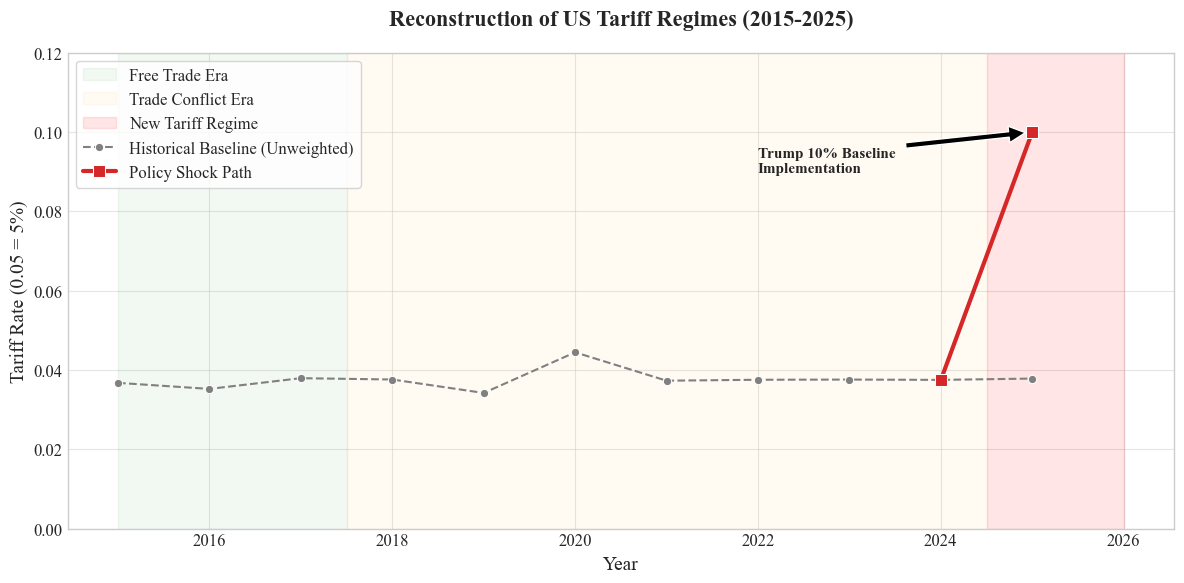

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 路径
BASE_DIR = r"G:\jupyter\2025APMCM"
DATA_FILE = os.path.join(BASE_DIR, "Cleaned_Data", "Annual_Tariff_Index.csv")
IMG_DIR = os.path.join(BASE_DIR, "Cleaned_Data")

# 读取数据
df = pd.read_csv(DATA_FILE)

# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- 绘制区域背景 (Regimes) ---
# 2015-2017: Obama/Trump Pre-Trade War
ax1.axvspan(2015, 2017.5, color='green', alpha=0.05, label='Free Trade Era')
# 2018-2024: Trade War Era
ax1.axvspan(2017.5, 2024.5, color='orange', alpha=0.05, label='Trade Conflict Era')
# 2025+: Policy Shock
ax1.axvspan(2024.5, 2026, color='red', alpha=0.1, label='New Tariff Regime')

# --- 绘制线条 ---
# 1. General Baseline (Historical)
sns.lineplot(data=df, x='Year', y='General_Tau', ax=ax1, marker='o', label='Historical Baseline (Unweighted)', color='gray', linestyle='--')

# 2. Simulated Shock (The Red Line)
# 构造断点数据：2024年是正常值，2025年跳升
shock_data = df[df['Year'] >= 2024].copy()
shock_data.loc[shock_data['Year'] == 2024, 'Simulated_Shock'] = shock_data.loc[shock_data['Year'] == 2024, 'General_Tau']
sns.lineplot(data=shock_data, x='Year', y='Simulated_Shock', ax=ax1, marker='s', markersize=8, linewidth=3, color='#d62728', label='Policy Shock Path')

# --- 标注 ---
ax1.annotate('Trump 10% Baseline\nImplementation', xy=(2025, 0.10), xytext=(2022, 0.09),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=11, fontweight='bold')

ax1.set_ylabel('Tariff Rate (0.05 = 5%)', fontsize=14)
ax1.set_xlabel('Year', fontsize=14)
ax1.set_title('Reconstruction of US Tariff Regimes (2015-2025)', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylim(0, 0.12)
ax1.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "Figure_2_Tariff_Shock_Index.png"), dpi=300)
print("Plot Saved.")